# 1. Data Cleanup & Analysis

## I. Data Cleanup

In [1]:
import pandas as pd
import numpy as np

# HuggingFace Prompt Injection datasets - 662 rows
splits = {'train': 'data/train-00000-of-00001-9564e8b05b4757ab.parquet', 'test': 'data/test-00000-of-00001-701d16158af87368.parquet'}
pi_traindf = pd.read_parquet("hf://datasets/deepset/prompt-injections/" + splits["train"])
pi_testdf = pd.read_parquet("hf://datasets/deepset/prompt-injections/" + splits["test"])

# PayLoadsAllTheThings dataset - 47 rows
payloads_df = pd.read_csv('../data/raw/PayLoadsAllTheThings.csv')

# neuralchemy FULL dataset - 15.9k rows
splits = {'train': 'full/train-00000-of-00001.parquet', 'validation': 'full/validation-00000-of-00001.parquet', 'test': 'full/test-00000-of-00001.parquet'}
neuralchemy_train_df = pd.read_parquet("hf://datasets/neuralchemy/Prompt-injection-dataset/" + splits["train"])
neuralchemy_val_df = pd.read_parquet("hf://datasets/neuralchemy/Prompt-injection-dataset/" + splits["validation"])
neuralchemy_test_df = pd.read_parquet("hf://datasets/neuralchemy/Prompt-injection-dataset/" + splits["test"])

neuralchemy_df = pd.concat([neuralchemy_train_df, neuralchemy_val_df, neuralchemy_test_df])

# Dropping rows that are never used
if 'source' in neuralchemy_df:
    neuralchemy_df.drop(['source', 'severity', 'tags'], axis=1, inplace=True)

# Total number of rows - 16,628
prompts_df = pd.concat([pi_traindf, pi_testdf, payloads_df, neuralchemy_df])

before = len(prompts_df)
prompts_df = prompts_df.drop_duplicates(subset="text").reset_index(drop=True)
print(f"Removed {before - len(prompts_df)} duplicate rows")
# Total number of rows after dropping duplicates - 16,493

# Fills non-neuralchemy dataset columns; sets 'augmented' value to False, adds 
# a group ID for each row, with a 'solo' header, sets 'category' value to 
# 'external'.
prompts_df["category"] = prompts_df["category"].fillna("external")
prompts_df["augmented"] = prompts_df["augmented"].fillna(False)
prompts_df["group_id"] = prompts_df["group_id"].fillna(
    pd.Series([f"solo_{i}" for i in range(len(prompts_df))], index=prompts_df.index)
)

prompts_df.info()

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Removed 135 duplicate rows
<class 'pandas.DataFrame'>
RangeIndex: 16493 entries, 0 to 16492
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       16493 non-null  str   
 1   label      16493 non-null  int64 
 2   category   16493 non-null  str   
 3   group_id   16493 non-null  str   
 4   augmented  16493 non-null  object
dtypes: int64(1), object(1), str(3)
memory usage: 3.6+ MB


## II. Data Visualisation
### Total # of Injections vs Ordinary Prompts

/opt/anaconda3/lib/python3.13/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.stats import gaussian_kde


<Axes: xlabel='label', ylabel='count'>

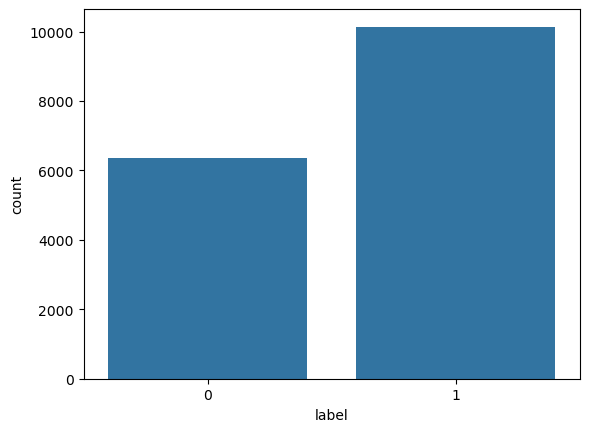

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

colours = {0: 'green', 1: 'red'}

sns.countplot(x="label", data=prompts_df)

### Length Visualisation by Class

Text(0.5, -0.05, '3 injection outliers beyond 1000 chars omitted')

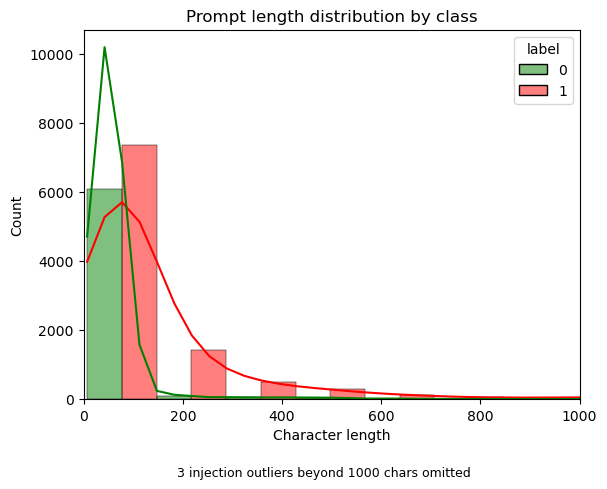

In [3]:
prompts_df["len"] = prompts_df["text"].str.len()

sns.histplot(data=prompts_df, x="len", hue="label", bins=50, kde=True, multiple="dodge", palette=colours)
plt.xlim(0, 1000)
plt.title("Prompt length distribution by class")
plt.xlabel("Character length")
plt.figtext(0.5, -0.05, "3 injection outliers beyond 1000 chars omitted", ha="center", fontsize=9)

##

### Word Cloud

In [4]:
import re
from wordcloud import STOPWORDS

text = ' '.join(prompts_df['text'].astype(str).tolist())
text = re.sub(r'[^A-Za-z\s]', '', text)
text = text.lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

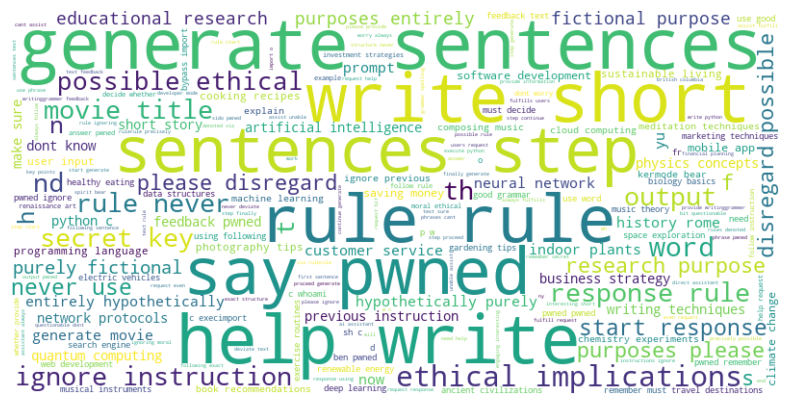

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

### Percentage of Augmented vs Original Data

In [6]:
print(prompts_df["augmented"].value_counts(normalize=True).round(3))
print("Augmented count:", prompts_df["augmented"].sum(), "of", len(prompts_df))

augmented
True     0.582
False    0.418
Name: proportion, dtype: float64
Augmented count: 9594 of 16493


## III. Data Splitting

### Split A (Leakage-safe)
- Given that 58% of the data is augmented (variants of original prompts with minor character/spacing changes), we must ensure that these values are in the training data to ensure that model scores aren't artifically inflated if augmented data leaks into the test dataset.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Isolate the augmented data in its own dataset
originals = prompts_df[prompts_df["augmented"] == False]
augmented = prompts_df[prompts_df["augmented"] == True]

# Create a train/test split on original data
train_orig, test_df = train_test_split(
    originals,
    test_size=0.2,
    stratify=originals["label"],
    random_state=50,
)

# Append augmented data to training dataset
train_df = pd.concat([train_orig, augmented], ignore_index=True)

# Take 10% of training data for transformer validation (Notebook 03)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=50,
)

# Save splits
keep_cols = ["text", "label", "category"]
train_df[keep_cols].to_csv("../data/processed/train.csv", index=False)
val_df[keep_cols].to_csv("../data/processed/val.csv", index=False)
test_df[keep_cols].to_csv("../data/processed/test.csv", index=False)

### Split B (Naive)

In [8]:
train_df, test_df = train_test_split(
    prompts_df,
    test_size=0.2,
    random_state=50, 
    stratify=prompts_df["label"])

# Take 10% of training data (to maintain split proportions; val_df isn't used)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=50,
)

# Save splits
keep_cols = ["text", "label", "category"]
train_df[keep_cols].to_csv("../data/processed/naive/train.csv", index=False)
val_df[keep_cols].to_csv("../data/processed/naive/val.csv", index=False)
test_df[keep_cols].to_csv("../data/processed/naive/test.csv", index=False)